In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from astropy.io import ascii


plt.style.use('plot_styles.mplstyle_new')

In [2]:
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

In [5]:
cendes2024=ascii.read("cendes_mrt.txt")

In [8]:
cendes2024.colnames

['Object', 'Tel', 'Code', 'Date', 'dt', 'Freq', 'l_S', 'S', 'e_S']

In [20]:
dict_events = {}

for name in np.unique(np.array(cendes2024['Object'])):
    print(name)
    dt_array_temp = np.array([])
    freq_array_temp = np.array([])
    fluxdensity_array_temp = np.array([])
    err_fluxdensity_array_temp = np.array([])
    for i in range(len(cendes2024['Object'])):
        if cendes2024['Object'][i] == name:
            # print(cendes2024['Object'][i], cendes2024['dt'][i],cendes2024['Freq'][i],cendes2024['S'][i],cendes2024['e_S'][i])
            dt_array_temp = np.append(dt_array_temp, cendes2024['dt'][i])
            freq_array_temp = np.append(freq_array_temp, cendes2024['Freq'][i])
            fluxdensity_array_temp = np.append(fluxdensity_array_temp, cendes2024['S'][i])
            err_fluxdensity_array_temp = np.append(err_fluxdensity_array_temp, cendes2024['e_S'][i])
    dict_events[name] = {'times (d)': dt_array_temp, 'freq (GHz)': freq_array_temp, 'flux density (mJy)': fluxdensity_array_temp, 'error (mJy)': err_fluxdensity_array_temp}

ASASSN-14ae
AT2017eqx
AT2018dyb
AT2018fyk
AT2018hco
AT2018lna
AT2018zr
AT2019dsg
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
PS16dtm
iPTF15af
iPTF16axa
iPTF16fnl


In [21]:
dict_events

{'ASASSN-14ae': {'times (d)': array([ 778., 2122., 2313., 2696., 2696., 2696., 2696., 2696., 2608.,
         3243., 3243., 3243., 3243., 3243., 3243., 3243., 3243., 3243.,
         3243., 3243., 3243.]),
  'freq (GHz)': array(['5', '3', '6', '3', '5', '7', '9', '11', '3', '1.25', '1.75',
         '2.5', '3.5', '5', '7', '9', '11', '13.5', '16.5', '20', '24'],
        dtype='<U32'),
  'flux density (mJy)': array([0.033, 0.42 , 0.09 , 0.334, 0.222, 0.169, 0.155, 0.15 , 0.47 ,
         3.12 , 0.72 , 0.68 , 0.604, 0.418, 0.446, 0.382, 0.361, 0.347,
         0.337, 0.303, 0.343]),
  'error (mJy)': masked_array(data=[0.   , 0.   , 0.015, 0.038, 0.018, 0.007, 0.01 , 0.001,
                     0.   , 0.   , 0.041, 0.029, 0.017, 0.08 , 0.011, 0.02 ,
                     0.025, 0.015, 0.022, 0.015, 0.014],
               mask=False,
         fill_value=1e+20)},
 'AT2017eqx': {'times (d)': array([1090., 1955.]),
  'freq (GHz)': array(['6', '6'], dtype='<U32'),
  'flux density (mJy)': array([0.01

In [57]:
plt.close('all')

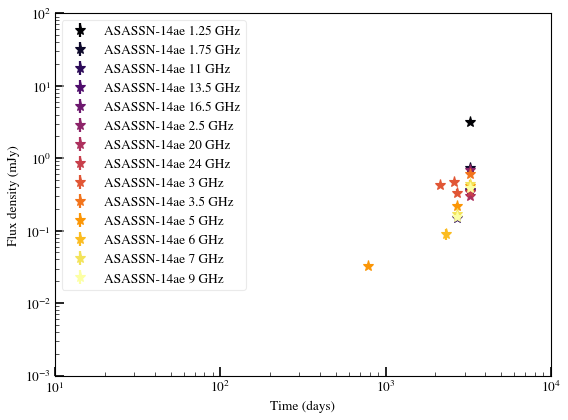

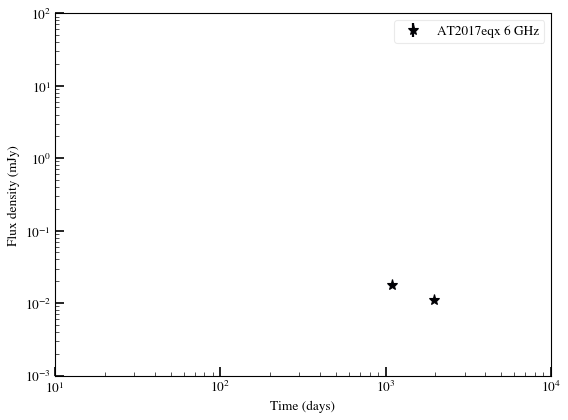

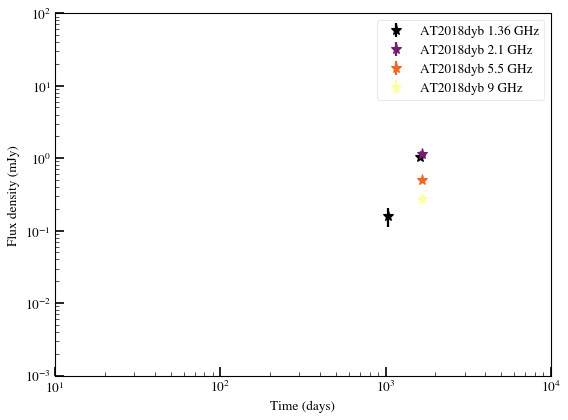

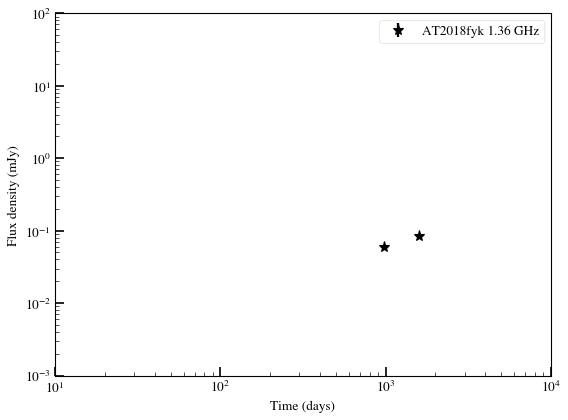

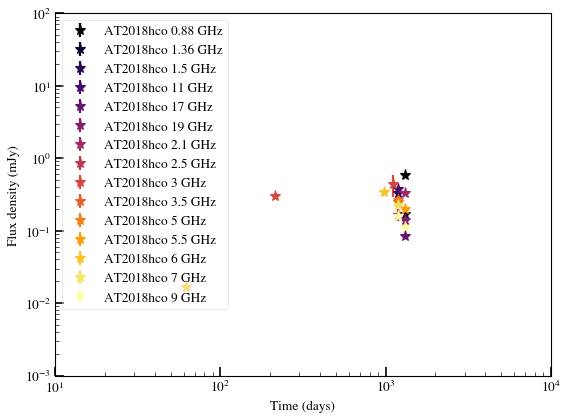

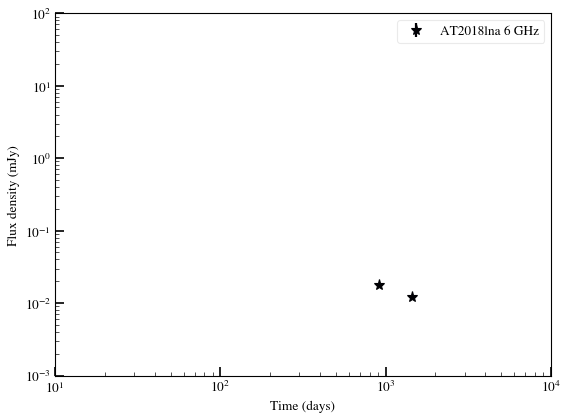

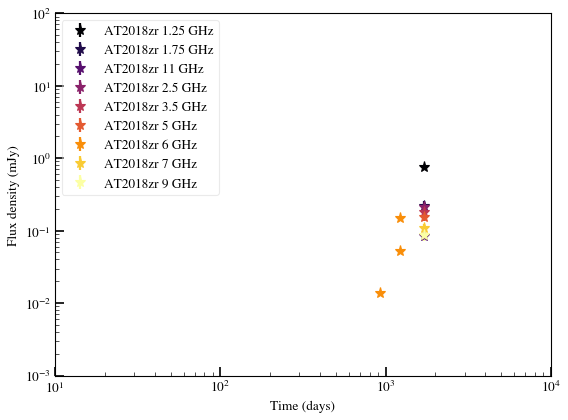

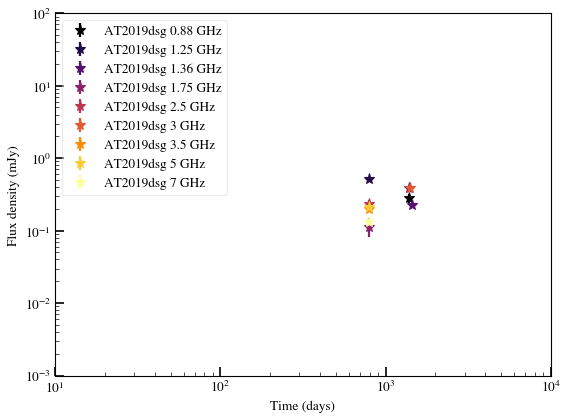

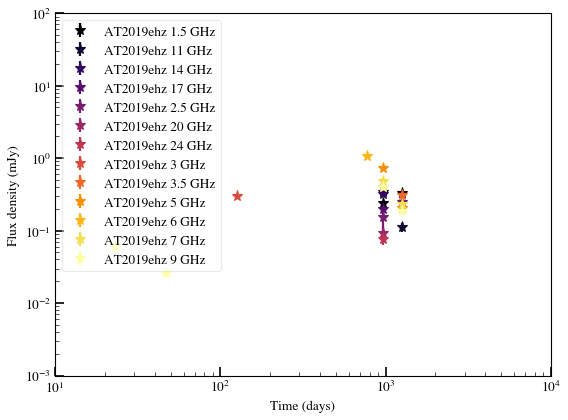

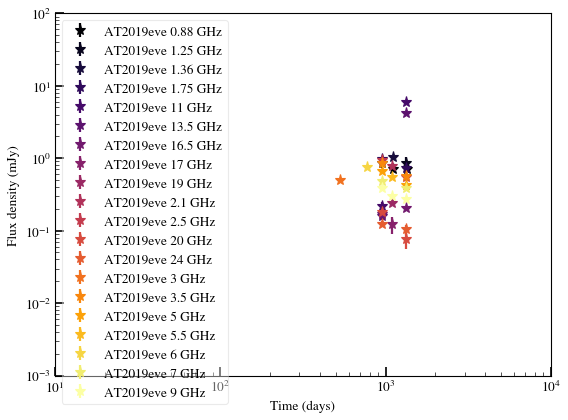

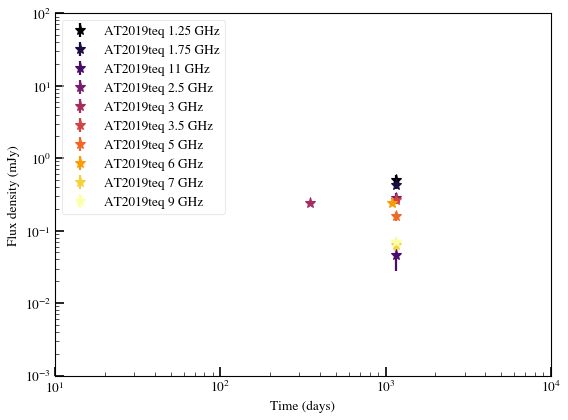

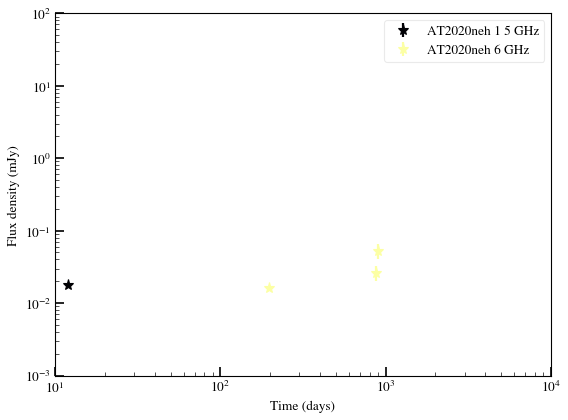

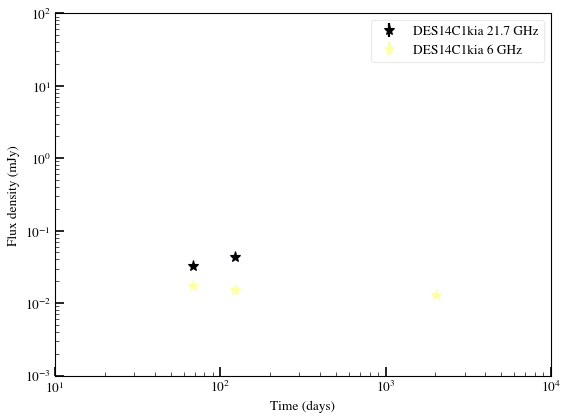

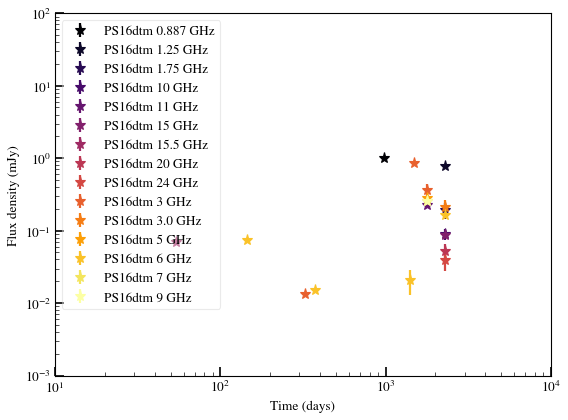

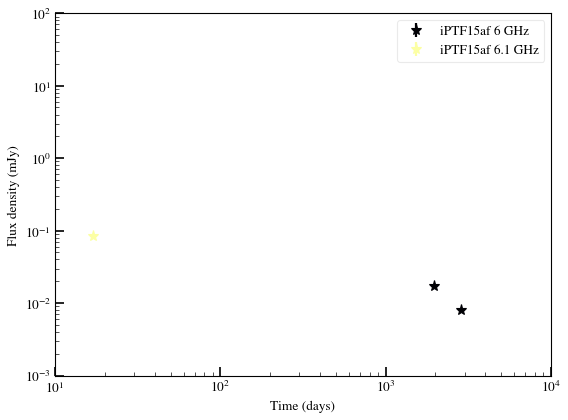

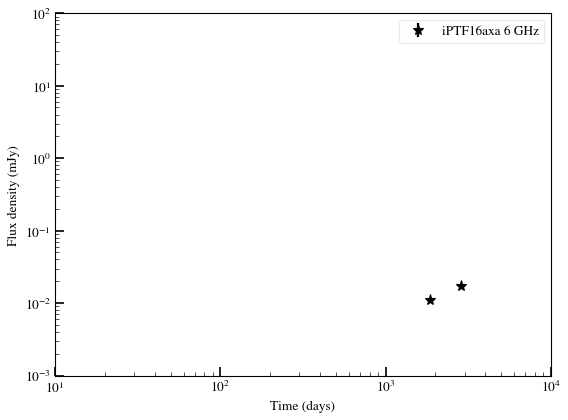

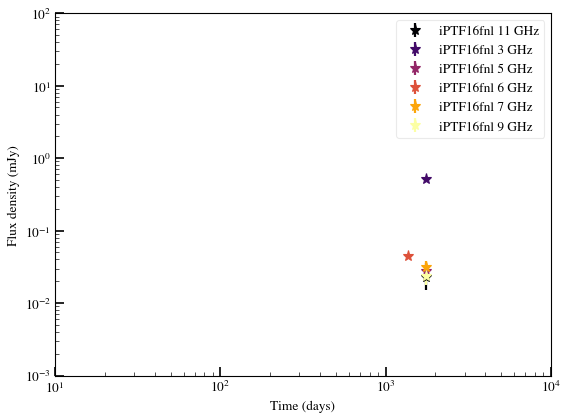

In [58]:
for event in dict_events.keys():
    # if event != 'ASASSN-14ae':
    #     continue
    colors_array = plt.cm.inferno(np.linspace(0, 1, len(np.unique(dict_events[event]['freq (GHz)']))))
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    fig,ax = plt.subplots(figsize=(8, 6))
    for freq, color in zip(np.unique(dict_events[event]['freq (GHz)']), colors_array):
        # print(color,freq)
        unique = True
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                if unique:
                    label = f'{event} {freq} GHz'
                else:
                    label = None
                ax.errorbar(dict_events[event]['times (d)'][i], dict_events[event]['flux density (mJy)'][i], yerr=dict_events[event]['error (mJy)'][i], fmt='*', color=color, label=label)
                unique=False
    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(10,1e4)
    ax.set_ylim(1e-3,1e2)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Flux density (mJy)')
    plt.legend()

1 5


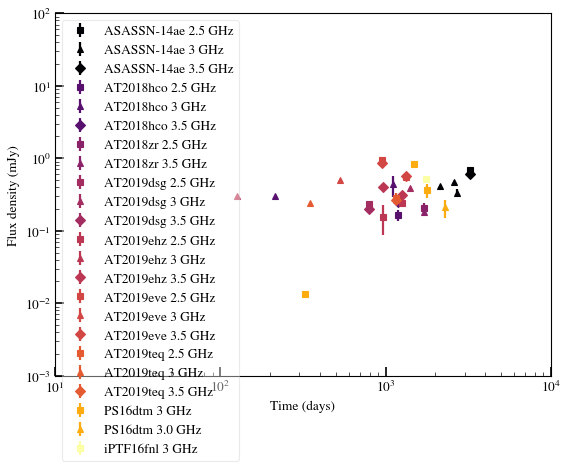

In [75]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','^','D','v','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)

        try:
            if np.abs(float(freq)-3) > 0.5:
                continue
        except:
            print(freq)
            continue
        unique = True
        marker_num+=1
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                if unique:
                    label = f'{event} {freq} GHz'
                else:
                    label = None
                ax.errorbar(dict_events[event]['times (d)'][i], dict_events[event]['flux density (mJy)'][i], yerr=dict_events[event]['error (mJy)'][i], fmt=marker_array[marker_num],ms=6, color=color, label=label)
                unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

1 5


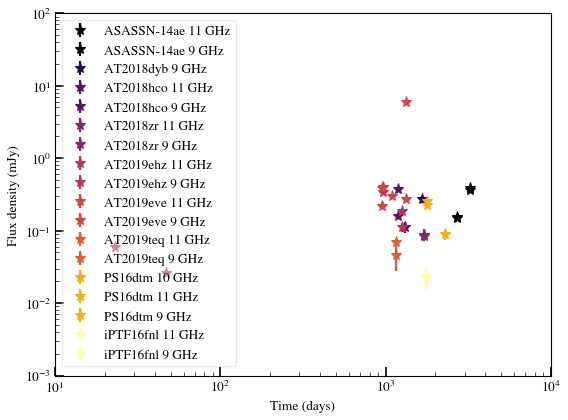

In [68]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)
        try:
            if np.abs(float(freq)-10) > 1:
                continue
        except:
            print(freq)
            continue
        unique = True
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                if unique:
                    label = f'{event} {freq} GHz'
                else:
                    label = None
                ax.errorbar(dict_events[event]['times (d)'][i], dict_events[event]['flux density (mJy)'][i], yerr=dict_events[event]['error (mJy)'][i], fmt='*', color=color, label=label)
                unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

1 5


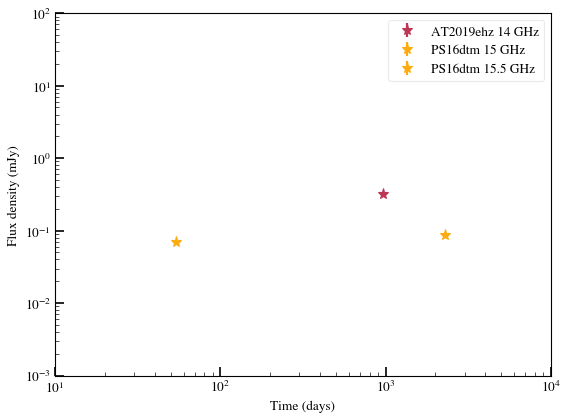

In [70]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)
        try:
            if np.abs(float(freq)-15) > 1:
                continue
        except:
            print(freq)
            continue
        unique = True
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                if unique:
                    label = f'{event} {freq} GHz'
                else:
                    label = None
                ax.errorbar(dict_events[event]['times (d)'][i], dict_events[event]['flux density (mJy)'][i], yerr=dict_events[event]['error (mJy)'][i], fmt='*', color=color, label=label)
                unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()